# SVM — Classification du Type de Peau

Ce notebook applique les machines à vecteurs de support (SVM) pour prédire le **type de peau** (Oily, Dry, Normal) à partir de données biométriques et environnementales.

**Dataset :** Skin Type Dataset  
**Target :** `Skin_Type` (3 classes : Dry, Normal, Oily)  
**Features :** Age, Gender, Hydration_Level, Oil_Level, Sensitivity, Humidity, Temperature

---
## Partie 1 : Préparation et Exploration des Données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Chargement du dataset ──────────────────────────────────────────────────────
# Remplacez le chemin ci-dessous par le chemin réel de votre fichier CSV
# Exemple Colab : from google.colab import files; files.upload()
df = pd.read_csv('Skin_Type_dataset.csv')   # <-- adaptez le nom du fichier

print("Forme du dataset :", df.shape)
df.head()

Forme du dataset : (10000, 10)


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,Female,Medium,High,Low,53.0,16.9,Oily,100.0,15.0
1,42,Male,Low,Low,High,32.6,15.4,Dry,36.8,62.0
2,36,Male,Medium,Medium,Low,65.5,14.0,Normal,100.0,24.5
3,35,Male,Medium,High,Medium,49.4,17.7,Normal,100.0,16.2
4,41,Male,Medium,High,Low,62.7,30.2,Oily,100.0,25.3


In [3]:
# ── Informations générales ─────────────────────────────────────────────────────
print("=== Types de colonnes ===")
print(df.dtypes)
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print("\n=== Statistiques descriptives (colonnes numériques) ===")
df.describe()

=== Types de colonnes ===
Age                  int64
Gender              object
Hydration_Level     object
Oil_Level           object
Sensitivity         object
Humidity           float64
Temperature        float64
Skin_Type           object
skin_score         float64
skin_age           float64
dtype: object

=== Valeurs manquantes ===
Age                0
Gender             0
Hydration_Level    0
Oil_Level          0
Sensitivity        0
Humidity           0
Temperature        0
Skin_Type          0
skin_score         0
skin_age           0
dtype: int64

=== Statistiques descriptives (colonnes numériques) ===


,Age,Humidity,Temperature,skin_score,skin_age
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,40.841500,49.970180,20.120070,76.322580,36.529470
std,12.030547,16.987268,5.573544,26.655636,17.752015
min,18.000000,20.000000,10.000000,2.300000,15.000000
25%,31.000000,34.400000,15.700000,49.600000,21.800000
50%,41.000000,49.600000,18.900000,90.000000,33.500000
75%,52.000000,62.800000,24.600000,100.000000,47.600000
max,59.000000,80.000000,34.900000,100.000000,79.000000


Distribution de Skin_Type :
Skin_Type
Normal         3084
Oily           2944
Dry            2500
Combination    1472
Name: count, dtype: int64


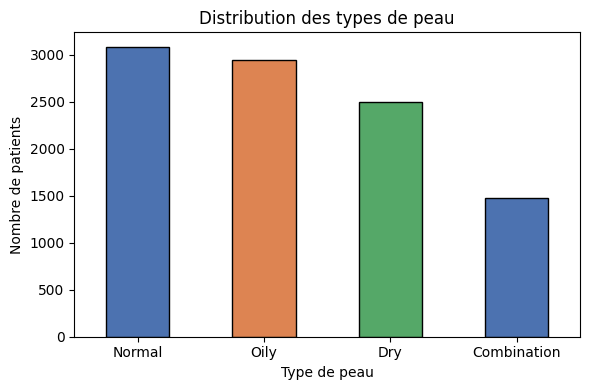

In [4]:
# ── Distribution de la variable cible ─────────────────────────────────────────
print("Distribution de Skin_Type :")
print(df['Skin_Type'].value_counts())

plt.figure(figsize=(6, 4))
df['Skin_Type'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
plt.title('Distribution des types de peau')
plt.xlabel('Type de peau')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

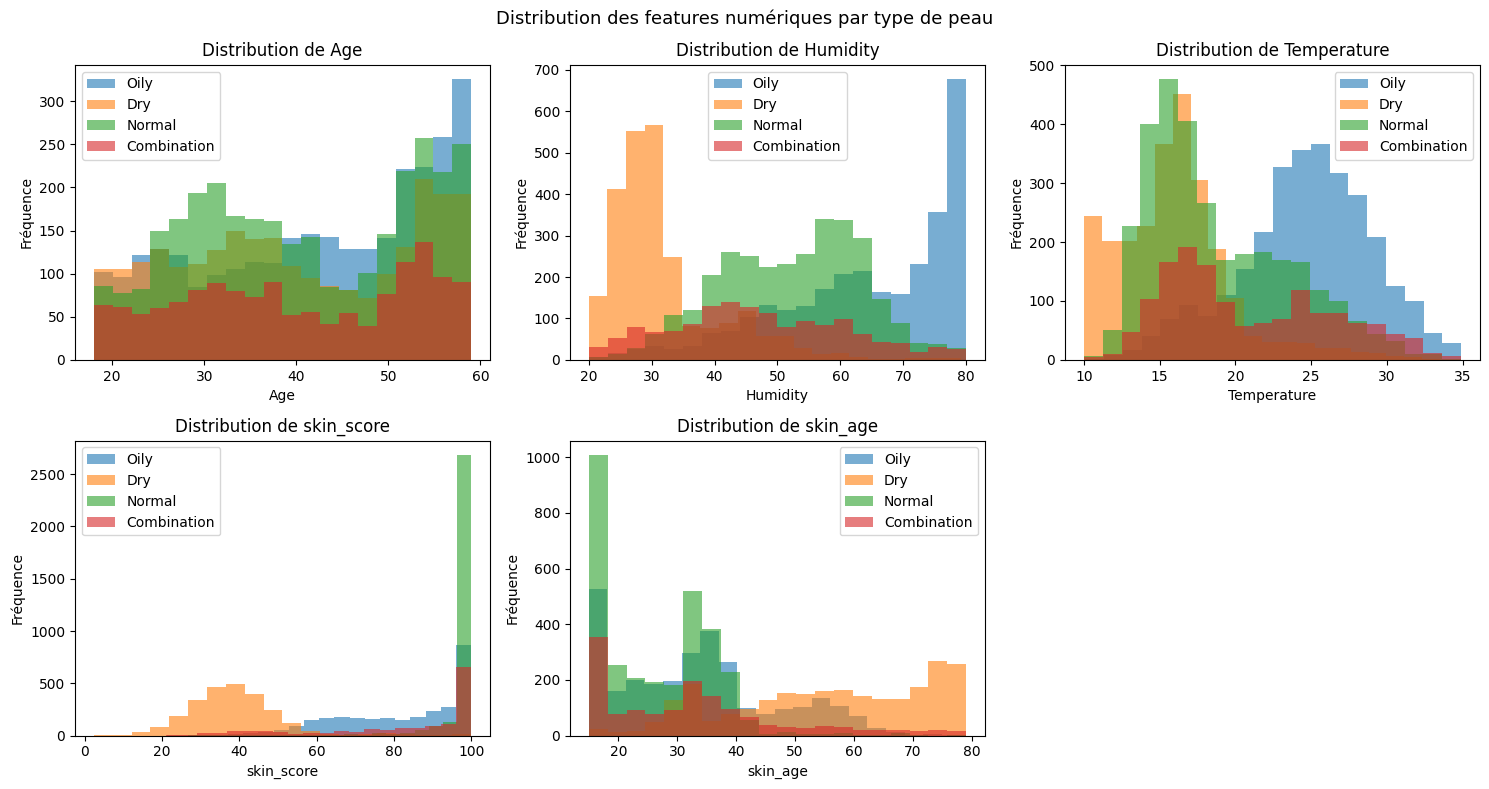

In [5]:
# ── Visualisation des features numériques par type de peau ────────────────────
numeric_cols = ['Age', 'Humidity', 'Temperature', 'skin_score', 'skin_age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for skin_type in df['Skin_Type'].unique():
        subset = df[df['Skin_Type'] == skin_type][col]
        axes[i].hist(subset, alpha=0.6, label=skin_type, bins=20)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend()

# Masquer le dernier subplot vide
axes[-1].set_visible(False)
plt.suptitle('Distribution des features numériques par type de peau', fontsize=13)
plt.tight_layout()
plt.show()

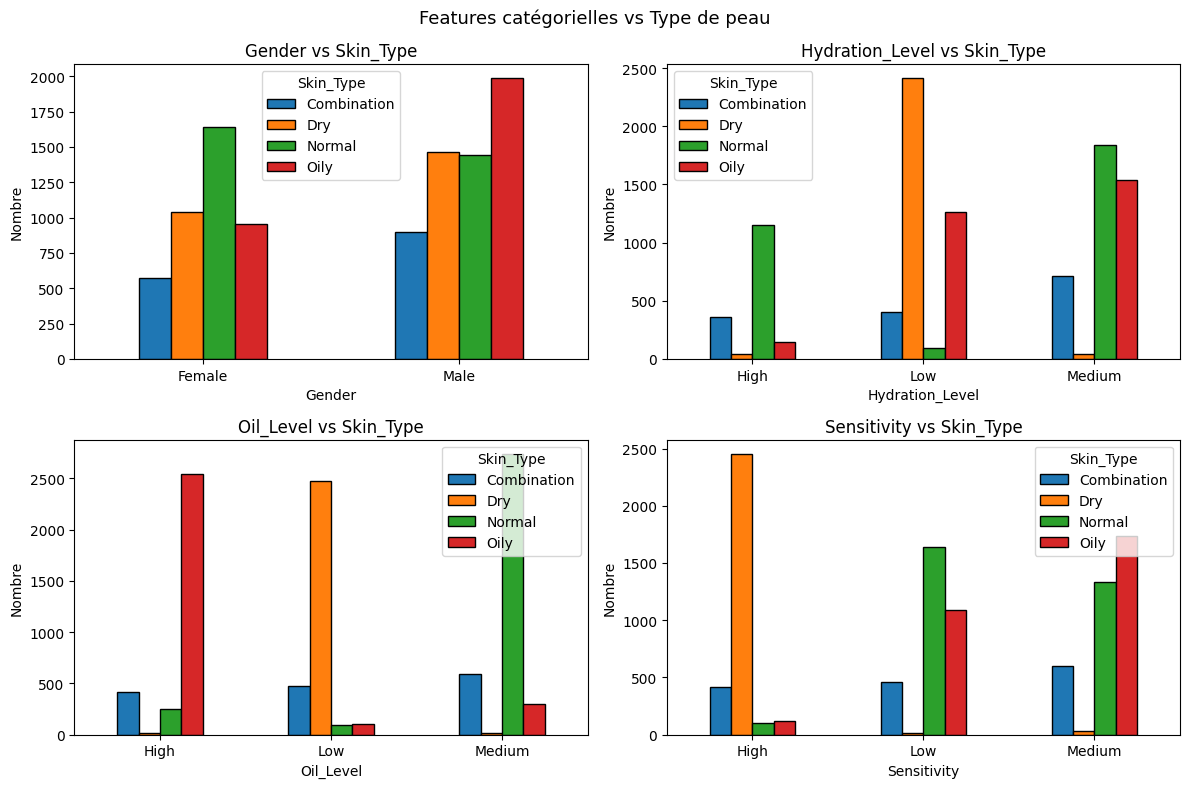

In [6]:
# ── Visualisation des features catégorielles ──────────────────────────────────
cat_cols = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Skin_Type'])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} vs Skin_Type')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Skin_Type')

plt.suptitle('Features catégorielles vs Type de peau', fontsize=13)
plt.tight_layout()
plt.show()

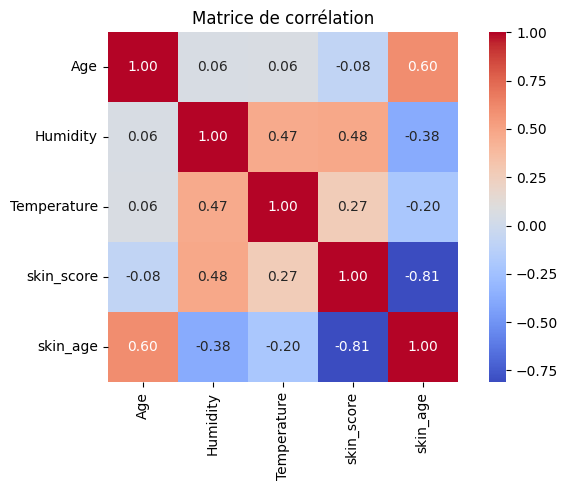

In [7]:
# ── Matrice de corrélation (features numériques) ──────────────────────────────
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

In [8]:
# ── Encodage des variables catégorielles ──────────────────────────────────────
# Colonnes à encoder avec LabelEncoder
cat_features = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']

le_dict = {}  # On sauvegarde les encodeurs pour pouvoir les réutiliser
df_encoded = df.copy()

for col in cat_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"{col} → classes : {list(le.classes_)} → codes : {list(range(len(le.classes_)))}")

# Encodage de la cible
le_target = LabelEncoder()
df_encoded['Skin_Type'] = le_target.fit_transform(df_encoded['Skin_Type'])
print(f"\nSkin_Type → classes : {list(le_target.classes_)} → codes : {list(range(len(le_target.classes_)))}")

df_encoded.head()

Gender → classes : ['Female', 'Male'] → codes : [0, 1]
Hydration_Level → classes : ['High', 'Low', 'Medium'] → codes : [0, 1, 2]
Oil_Level → classes : ['High', 'Low', 'Medium'] → codes : [0, 1, 2]
Sensitivity → classes : ['High', 'Low', 'Medium'] → codes : [0, 1, 2]

Skin_Type → classes : ['Combination', 'Dry', 'Normal', 'Oily'] → codes : [0, 1, 2, 3]


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,0,2,0,1,53.0,16.9,3,100.0,15.0
1,42,1,1,1,0,32.6,15.4,1,36.8,62.0
2,36,1,2,2,1,65.5,14.0,2,100.0,24.5
3,35,1,2,0,2,49.4,17.7,2,100.0,16.2
4,41,1,2,0,1,62.7,30.2,3,100.0,25.3


In [9]:
# ── Séparation features / cible et train-test split ───────────────────────────
# On retire skin_score et skin_age si on les considère comme des 'leakage' potentiel
# (ils peuvent résumer directement le type de peau). Décommentez pour les inclure.
FEATURES = ['Age', 'Gender', 'Hydration_Level', 'Oil_Level',
            'Sensitivity', 'Humidity', 'Temperature']
# FEATURES += ['skin_score', 'skin_age']  # décommentez pour les ajouter

X = df_encoded[FEATURES]
y = df_encoded['Skin_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Taille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")
print(f"\nDistribution y_train :\n{y_train.value_counts()}")
print(f"\nDistribution y_test :\n{y_test.value_counts()}")

Taille train : (8000, 7)
Taille test  : (2000, 7)

Distribution y_train :
Skin_Type
2    2467
3    2355
1    2000
0    1178
Name: count, dtype: int64

Distribution y_test :
Skin_Type
2    617
3    589
1    500
0    294
Name: count, dtype: int64


In [10]:
# ── Normalisation (StandardScaler) ────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Données normalisées — Moyenne train (doit ≈ 0) :", X_train_scaled.mean(axis=0).round(3))
print("Écart-type train (doit ≈ 1) :", X_train_scaled.std(axis=0).round(3))

Données normalisées — Moyenne train (doit ≈ 0) : [-0. -0. -0.  0. -0. -0. -0.]
Écart-type train (doit ≈ 1) : [1. 1. 1. 1. 1. 1. 1.]


---
## Partie 2 : Entraînement SVM avec Différents Noyaux

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[kernel] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f"Kernel : {kernel:<10}  |  Accuracy : {acc:.4f}")

Kernel : linear      |  Accuracy : 0.7740
Kernel : poly        |  Accuracy : 0.7925
Kernel : rbf         |  Accuracy : 0.7920
Kernel : sigmoid     |  Accuracy : 0.6280


In [12]:
# ── Rapport de classification pour chaque noyau ───────────────────────────────
class_names = le_target.classes_

for kernel in kernels:
    print(f"\n{'='*50}")
    print(f"Noyau : {kernel.upper()}")
    print(classification_report(
        y_test,
        results[kernel]['y_pred'],
        target_names=class_names
    ))


Noyau : LINEAR
              precision    recall  f1-score   support

 Combination       0.52      0.08      0.14       294
         Dry       0.81      0.98      0.89       500
      Normal       0.74      0.87      0.80       617
        Oily       0.79      0.84      0.82       589

    accuracy                           0.77      2000
   macro avg       0.72      0.69      0.66      2000
weighted avg       0.74      0.77      0.73      2000


Noyau : POLY
              precision    recall  f1-score   support

 Combination       0.51      0.22      0.31       294
         Dry       0.91      0.95      0.93       500
      Normal       0.76      0.87      0.81       617
        Oily       0.80      0.86      0.83       589

    accuracy                           0.79      2000
   macro avg       0.74      0.73      0.72      2000
weighted avg       0.77      0.79      0.77      2000


Noyau : RBF
              precision    recall  f1-score   support

 Combination       0.52      0.1

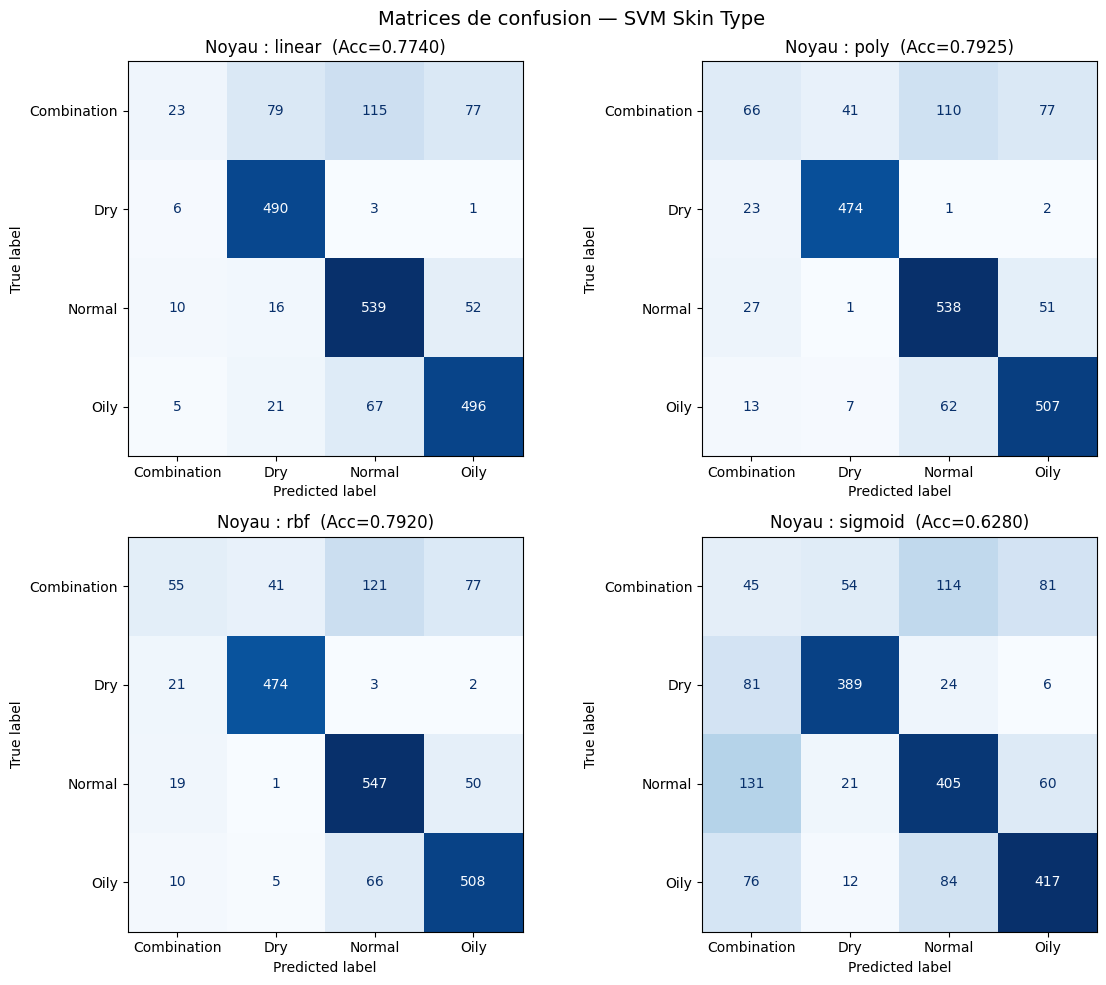

In [13]:
# ── Matrices de confusion (4 noyaux) ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, kernel in zip(axes.flatten(), kernels):
    cm = confusion_matrix(y_test, results[kernel]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Noyau : {kernel}  (Acc={results[kernel]["accuracy"]:.4f})')

plt.suptitle('Matrices de confusion — SVM Skin Type', fontsize=14)
plt.tight_layout()
plt.show()

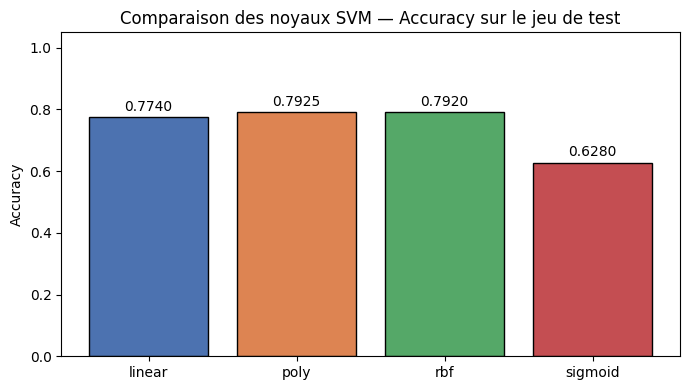


Meilleur noyau : poly (Accuracy = 0.7925)


In [14]:
# ── Comparaison des accuracy ──────────────────────────────────────────────────
acc_values = [results[k]['accuracy'] for k in kernels]

plt.figure(figsize=(7, 4))
bars = plt.bar(kernels, acc_values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], edgecolor='black')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Comparaison des noyaux SVM — Accuracy sur le jeu de test')
for bar, val in zip(bars, acc_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}',
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

best_kernel = max(results, key=lambda k: results[k]['accuracy'])
print(f"\nMeilleur noyau : {best_kernel} (Accuracy = {results[best_kernel]['accuracy']:.4f})")

---
## Partie 3 : Optimisation des Hyperparamètres par GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Grille de paramètres hyper-réduite (FAST)
param_grid_fast = {
    'C'      : [0.1, 1, 10],            # Dropped 0.01 and 100 (C=100 causes massive delays)
    'gamma'  : ['scale', 0.1],          # Kept only the two most reliable options
    'kernel' : ['linear', 'rbf']        # Completely removed 'poly' (the ultimate time-waster)
}

svc = SVC(random_state=42)

grid_search = GridSearchCV(
    svc,
    param_grid_fast,
    cv=3,                 # Reduced cross-validation from 5 to 3
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nMeilleurs paramètres :", grid_search.best_params_)
print(f"Meilleure accuracy CV : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Meilleurs paramètres : {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Meilleure accuracy CV : 0.7961


In [17]:
# ── Évaluation du meilleur modèle ─────────────────────────────────────────────
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Accuracy du meilleur modèle sur le test : {acc_best:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_best, target_names=class_names))

Accuracy du meilleur modèle sur le test : 0.7925

Rapport de classification :
              precision    recall  f1-score   support

 Combination       0.54      0.18      0.27       294
         Dry       0.91      0.95      0.93       500
      Normal       0.74      0.89      0.81       617
        Oily       0.80      0.87      0.83       589

    accuracy                           0.79      2000
   macro avg       0.75      0.72      0.71      2000
weighted avg       0.77      0.79      0.77      2000



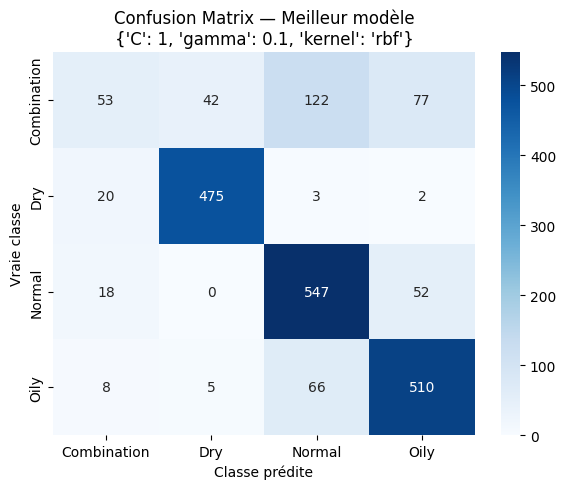

In [18]:
# ── Matrice de confusion — Meilleur modèle ────────────────────────────────────
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — Meilleur modèle\n{grid_search.best_params_}')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

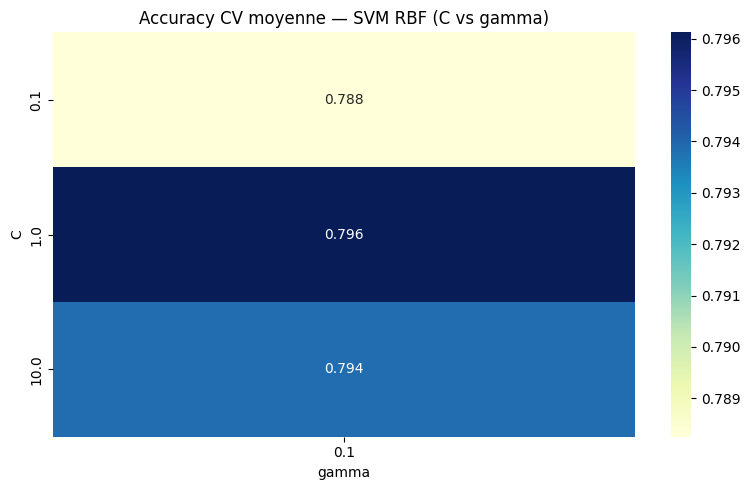

In [19]:
# ── Visualisation de l'impact de C et gamma (noyau RBF) ──────────────────────
# Extraire les résultats CV pour kernel=rbf
cv_results = pd.DataFrame(grid_search.cv_results_)
rbf_results = cv_results[cv_results['param_kernel'] == 'rbf'].copy()
rbf_results['param_C']     = rbf_results['param_C'].astype(float)
rbf_results['param_gamma'] = rbf_results['param_gamma'].apply(
    lambda x: str(x)  # gamma peut être 'scale' ou 'auto'
)

# Pivot uniquement pour les valeurs gamma numériques
rbf_numeric = rbf_results[rbf_results['param_gamma'].apply(
    lambda x: x not in ('scale', 'auto')
)].copy()
rbf_numeric['param_gamma'] = rbf_numeric['param_gamma'].astype(float)

pivot = rbf_numeric.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Accuracy CV moyenne — SVM RBF (C vs gamma)')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

---
## Partie 4 : Comparaison One-vs-One (OvO) vs One-vs-Rest (OvR)

In [20]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
import time

# Récupération des meilleurs hyperparamètres
best_C      = grid_search.best_params_.get('C', 10)
best_gamma  = grid_search.best_params_.get('gamma', 'scale')
best_kernel = grid_search.best_params_.get('kernel', 'rbf')

print(f"Paramètres utilisés : kernel={best_kernel}, C={best_C}, gamma={best_gamma}")

# ── Stratégie OvO ─────────────────────────────────────────────────────────────
print("\nEntraînement One-vs-One (OvO)...")
t0 = time.time()
ovo_clf = OneVsOneClassifier(
    SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, random_state=42),
    n_jobs=-1
)
ovo_clf.fit(X_train_scaled, y_train)
ovo_time = time.time() - t0
y_pred_ovo = ovo_clf.predict(X_test_scaled)
acc_ovo = accuracy_score(y_test, y_pred_ovo)
print(f"Temps OvO : {ovo_time:.2f}s  |  Accuracy OvO : {acc_ovo:.4f}")

# ── Stratégie OvR ─────────────────────────────────────────────────────────────
print("\nEntraînement One-vs-Rest (OvR)...")
t0 = time.time()
ovr_clf = OneVsRestClassifier(
    SVC(kernel=best_kernel, C=best_C, gamma=best_gamma, random_state=42),
    n_jobs=-1
)
ovr_clf.fit(X_train_scaled, y_train)
ovr_time = time.time() - t0
y_pred_ovr = ovr_clf.predict(X_test_scaled)
acc_ovr = accuracy_score(y_test, y_pred_ovr)
print(f"Temps OvR : {ovr_time:.2f}s  |  Accuracy OvR : {acc_ovr:.4f}")

Paramètres utilisés : kernel=rbf, C=1, gamma=0.1

Entraînement One-vs-One (OvO)...
Temps OvO : 1.54s  |  Accuracy OvO : 0.7925

Entraînement One-vs-Rest (OvR)...
Temps OvR : 4.78s  |  Accuracy OvR : 0.7950


In [21]:
# ── Rapports de classification OvO & OvR ──────────────────────────────────────
print("=== Rapport OvO ===")
print(classification_report(y_test, y_pred_ovo, target_names=class_names))

print("=== Rapport OvR ===")
print(classification_report(y_test, y_pred_ovr, target_names=class_names))

=== Rapport OvO ===
              precision    recall  f1-score   support

 Combination       0.54      0.18      0.27       294
         Dry       0.91      0.95      0.93       500
      Normal       0.74      0.89      0.81       617
        Oily       0.80      0.87      0.83       589

    accuracy                           0.79      2000
   macro avg       0.75      0.72      0.71      2000
weighted avg       0.77      0.79      0.77      2000

=== Rapport OvR ===
              precision    recall  f1-score   support

 Combination       0.60      0.16      0.25       294
         Dry       0.90      0.97      0.93       500
      Normal       0.74      0.89      0.81       617
        Oily       0.80      0.87      0.83       589

    accuracy                           0.80      2000
   macro avg       0.76      0.72      0.71      2000
weighted avg       0.78      0.80      0.76      2000



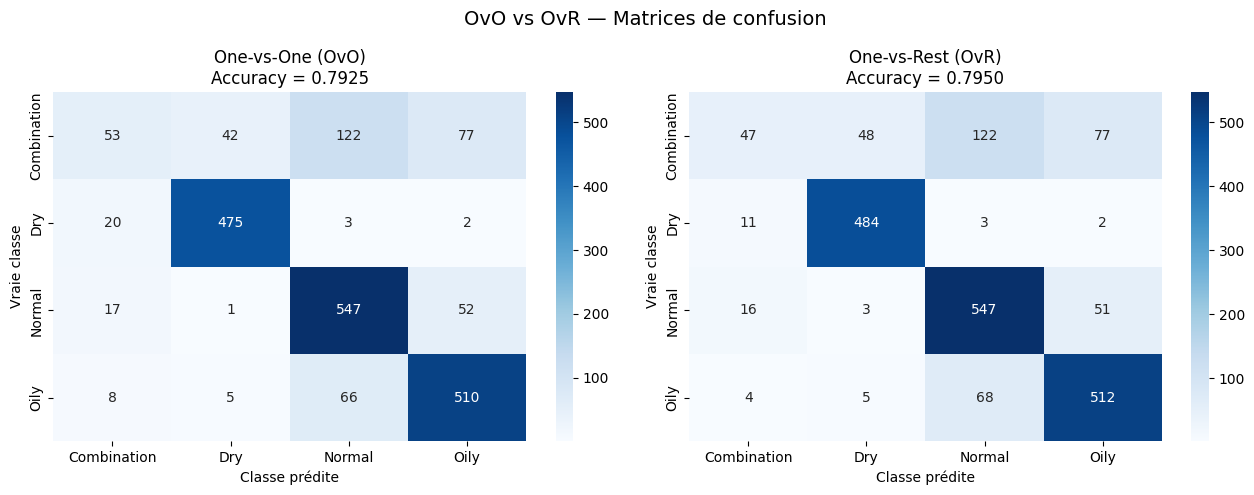

In [22]:
# ── Matrices de confusion OvO vs OvR ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_ovo, y_pred_ovr],
    ['One-vs-One (OvO)', 'One-vs-Rest (OvR)']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{title}\nAccuracy = {acc:.4f}')
    ax.set_ylabel('Vraie classe')
    ax.set_xlabel('Classe prédite')

plt.suptitle('OvO vs OvR — Matrices de confusion', fontsize=14)
plt.tight_layout()
plt.show()


=== Tableau récapitulatif OvO vs OvR ===
       Stratégie  Accuracy  Temps (s)
OvO (défaut SVC)    0.7925       1.54
             OvR    0.7950       4.78


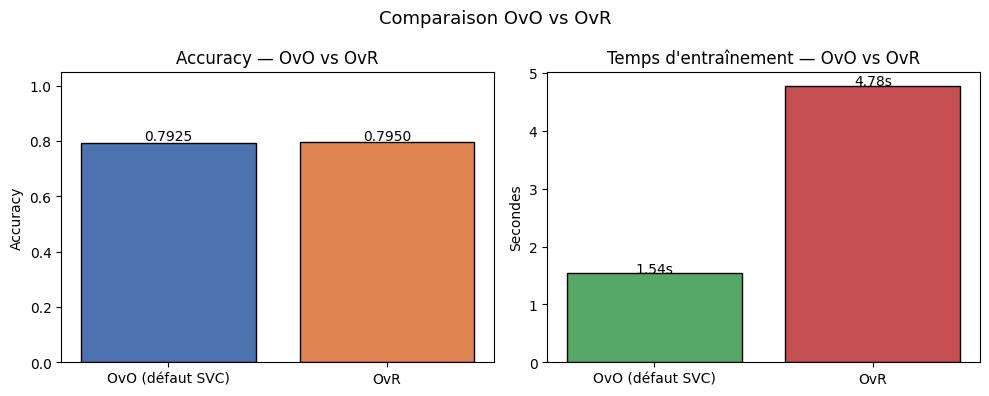

In [23]:
# ── Tableau récapitulatif final ───────────────────────────────────────────────
summary = pd.DataFrame({
    'Stratégie' : ['OvO (défaut SVC)', 'OvR'],
    'Accuracy'  : [acc_ovo, acc_ovr],
    'Temps (s)' : [round(ovo_time, 2), round(ovr_time, 2)]
})

print("\n=== Tableau récapitulatif OvO vs OvR ===")
print(summary.to_string(index=False))

# Graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(summary['Stratégie'], summary['Accuracy'],
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy — OvO vs OvR')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(summary['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(summary['Stratégie'], summary['Temps (s)'],
            color=['#55A868', '#C44E52'], edgecolor='black')
axes[1].set_title('Temps d\'entraînement — OvO vs OvR')
axes[1].set_ylabel('Secondes')
for i, v in enumerate(summary['Temps (s)']):
    axes[1].text(i, v + 0.01, f'{v}s', ha='center', fontsize=10)

plt.suptitle('Comparaison OvO vs OvR', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusion

| Étape | Résultat clé |
|-------|--------------|
| **Meilleur noyau (Partie 2)** | À compléter après exécution |
| **Meilleurs hyperparamètres (GridSearch)** | À compléter après exécution |
| **Accuracy test — Meilleur modèle** | À compléter après exécution |
| **OvO vs OvR** | À compléter après exécution |

**Points clés :**
- Les variables catégorielles (`Gender`, `Hydration_Level`, `Oil_Level`, `Sensitivity`) ont été encodées avec `LabelEncoder`.
- La normalisation par `StandardScaler` est indispensable pour que le SVM converge correctement.
- Le `GridSearchCV` avec validation croisée à 5 plis permet de sélectionner les meilleurs hyperparamètres `C`, `gamma` et `kernel`.
- Le SVC de sklearn utilise **OvO par défaut** pour la classification multiclasse, ce qui est souvent plus précis pour un petit nombre de classes.